# การสร้างกราฟ Spatio-Temporal สำหรับ PM2.5 ภาคเหนือของประเทศไทย

โน้ตบุ๊กนี้แสดงวิธีการสร้างกราฟ Heterogeneous Graph สำหรับโมเดล Spatio-Temporal GNN
โดยอธิบาย **3 ประเภทของเส้นเชื่อม (Edge Types)** และการตรวจสอบความถูกต้อง:

- **Type A** — เส้นเชื่อมเชิงพื้นที่แบบสถิต (Static Spatial): สถานีที่อยู่ห่างกันไม่เกิน 100 กม.
- **Type B** — เส้นเชื่อมตามทิศทางลม (Wind-Aware Dynamic): สถานีที่อยู่ห่างกันไม่เกิน 200 กม.
  และทิศทางลมสอดคล้องกับทิศทางจากต้นทางไปปลายทาง
- **Type C** — เส้นเชื่อมจากจุดเผาไหม้ (Hotspot Influence): กลุ่ม Hotspot ที่อยู่ห่างจากสถานีไม่เกิน 500 กม.
  และทิศทางลมพัดไปทางสถานี

ข้อมูลอ้างอิง: วันที่ 15 มีนาคม 2024 (ช่วงฤดูเผาไหม้สูงสุด)

In [1]:
# Cell 2 — Setup
import os
import sys
from pathlib import Path

# Resolve repo root robustly — works when run via nbconvert from any CWD.
# Walk up from CWD until we find the directory that contains both src/ and data/.
_candidate = Path(os.getcwd()).resolve()
_repo_root = None
for _p in [_candidate] + list(_candidate.parents):
    if (_p / "src").is_dir() and (_p / "data").is_dir():
        _repo_root = _p
        break
if _repo_root is None:
    raise RuntimeError(
        f"Cannot locate repo root (looking for src/ + data/) from {_candidate}. "
        "Run nbconvert from the repo root: "
        "jupyter nbconvert --to notebook --execute --inplace notebooks/02_graph_construction_viz.ipynb"
    )
os.chdir(str(_repo_root))
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

import warnings

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr  # noqa: F401  (imported for type compatibility with build_graph)

warnings.filterwarnings("ignore")

from src.data.graph_builder import _DEFAULT_CONFIG, build_graph

# Ensure figures output directory exists
Path("notebooks/figures").mkdir(exist_ok=True, parents=True)

# ---- Load data ----
df_stations = pd.read_parquet("data/processed/stations_metadata.parquet")
# graph_builder expects 'station_id' column
df_stations = df_stations.rename(columns={"location_id": "station_id"})

df_hotspots_all = pd.read_parquet("data/processed/hotspots.parquet")
df_dataset = pd.read_parquet("data/processed/dataset.parquet")

print(f"Repo root     : {_repo_root}")
print(f"Stations      : {len(df_stations)}")
print(f"Hotspot rows  : {len(df_hotspots_all)}")
print(f"Dataset rows  : {len(df_dataset)}")
print()
print("Station columns :", df_stations.columns.tolist())
print("Hotspot columns :", df_hotspots_all.columns.tolist())
print("Dataset columns :", df_dataset.columns.tolist())

Repo root     : D:\งาน\NSC\pm25-stgnn-thailand
Stations      : 18
Hotspot rows  : 26839
Dataset rows  : 631152

Station columns : ['station_id', 'name', 'lat', 'lon', 'provider', 'datetime_first', 'datetime_last', 'sensor_id_pm25']
Hotspot columns : ['date', 'cluster_id', 'centroid_lat', 'centroid_lon', 'total_frp', 'point_count', 'country']
Dataset columns : ['timestamp', 'station_id', 'pm25_raw', 'pm25_scaled', 'mask_in_loss', 'exclude_from_training', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']


In [2]:
# Cell 3 — Select reference timestep
REFERENCE_DATE = "2024-03-15"   # peak burning season
REFERENCE_TS = pd.Timestamp("2024-03-15 06:00:00", tz="UTC")

# Filter hotspots for the reference date.
# The 'date' column is object dtype (string) — convert to date for comparison.
ref_date = pd.to_datetime(REFERENCE_DATE).date()


def _to_date(x):
    """Coerce value that is either a date or a date-string to datetime.date."""
    return x if hasattr(x, "year") else pd.to_datetime(x).date()


df_hotspots = df_hotspots_all[
    df_hotspots_all["date"].apply(_to_date) == ref_date
].reset_index(drop=True)

# Get station features at reference timestamp from dataset.
ts_data = df_dataset[df_dataset["timestamp"] == REFERENCE_TS].set_index("station_id")

feature_cols = ["pm25_scaled", "hour_sin", "hour_cos", "doy_sin", "doy_cos"]
for col in feature_cols:
    if col in ts_data.columns:
        df_stations[col] = df_stations["station_id"].map(ts_data[col])
    else:
        df_stations[col] = float("nan")

print(f"Reference timestamp              : {REFERENCE_TS}")
print(f"Hotspots on {REFERENCE_DATE}     : {len(df_hotspots)}")
print(f"Stations with features at ref TS : {ts_data.shape[0]}")
print()
print("Station feature sample (first 5 rows):")
print(df_stations[["name", "lat", "lon"] + feature_cols].head(5).to_string(index=False))

Reference timestamp              : 2024-03-15 06:00:00+00:00
Hotspots on 2024-03-15     : 10
Stations with features at ref TS : 18

Station feature sample (first 5 rows):
                                               name       lat       lon  pm25_scaled  hour_sin      hour_cos  doy_sin  doy_cos
Natural Resources and Environment Office, Chiangrai 19.909217 99.823467     3.404546       1.0 -4.371139e-08  0.96113 0.276097
                Health Promotion Hospital Banthasri 18.426783 99.757633     5.513699       1.0 -4.371139e-08  0.96113 0.276097
                               Maesai Health Office 20.427325 99.883842     8.336842       1.0 -4.371139e-08  0.96113 0.276097
                   Meteorological stations, Lampang 18.278333 99.506467     6.950064       1.0 -4.371139e-08  0.96113 0.276097
                         Yupparaj Wittayalai School 18.790933 98.990000     6.864596       1.0 -4.371139e-08  0.96113 0.276097


In [3]:
# Cell 4 — Build reference graph (NE wind)
config_ne = {
    **_DEFAULT_CONFIG,
    "wind_mode": "constant_ne",
    "synthetic_u": 3.5,
    "synthetic_v": 3.5,
}
graph_ne = build_graph(df_stations, df_hotspots, None, config_ne)

n_a = graph_ne["station", "type_a", "station"].edge_index.shape[1]
n_b = graph_ne["station", "type_b", "station"].edge_index.shape[1]
n_c = graph_ne["hotspot", "type_c", "station"].edge_index.shape[1]

print("Reference graph (NE wind, 2024-03-15):")
print(f"  Station nodes : {graph_ne['station'].x.shape[0]}")
print(f"  Hotspot nodes : {graph_ne['hotspot'].x.shape[0]}")
print(f"  Type A edges  : {n_a}  (static spatial, <=100 km)")
print(f"  Type B edges  : {n_b}  (wind-aware, <=200 km, align>0.3)")
print(f"  Type C edges  : {n_c}  (hotspot influence, <=500 km, align>0.4)")

Reference graph (NE wind, 2024-03-15):
  Station nodes : 18
  Hotspot nodes : 10
  Type A edges  : 74  (static spatial, <=100 km)
  Type B edges  : 71  (wind-aware, <=200 km, align>0.3)
  Type C edges  : 70  (hotspot influence, <=500 km, align>0.4)


In [4]:
# Helper — reusable plot_graph function


def plot_graph(ax, df_st, df_hs, graph, edge_type, title, wind_u=None, wind_v=None):
    """Draw station nodes, hotspot nodes, and edges of one type on ax.

    Args:
        ax: Matplotlib Axes.
        df_st: Station DataFrame with lat, lon, name columns.
        df_hs: Hotspot DataFrame with centroid_lat, centroid_lon, total_frp.
        graph: HeteroData from build_graph.
        edge_type: One of 'type_a', 'type_b', 'type_c', or 'all'.
        title: Axes title string.
        wind_u: Eastward wind component for indicator arrow (optional).
        wind_v: Northward wind component for indicator arrow (optional).
    """
    lats = df_st["lat"].values
    lons = df_st["lon"].values

    def _draw_type_a():
        ei = graph["station", "type_a", "station"].edge_index.numpy()
        ea = graph["station", "type_a", "station"].edge_attr.numpy()
        if ei.shape[1] == 0:
            return
        weights = ea[:, 0]
        vmin, vmax = weights.min(), weights.max()
        if vmin == vmax:
            vmax = vmin + 1e-6
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = cm.Blues
        for k in range(ei.shape[1]):
            i, j = ei[0, k], ei[1, k]
            ax.plot(
                [lons[i], lons[j]], [lats[i], lats[j]],
                color=cmap(norm(weights[k])), alpha=0.6, linewidth=1.0,
            )

    def _draw_type_b():
        ei = graph["station", "type_b", "station"].edge_index.numpy()
        ea = graph["station", "type_b", "station"].edge_attr.numpy()
        if ei.shape[1] == 0:
            ax.text(99.25, 18.5, "No Type B edges", ha="center", fontsize=9, color="gray")
            return
        weights = ea[:, 0]
        vmin = weights.min() if len(weights) > 0 else 0.0
        vmax = weights.max() if len(weights) > 0 else 1.0
        if vmin == vmax:
            vmax = vmin + 1e-6
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = cm.Oranges
        for k in range(ei.shape[1]):
            i, j = ei[0, k], ei[1, k]
            ax.annotate(
                "",
                xy=(lons[j], lats[j]),
                xytext=(lons[i], lats[i]),
                arrowprops=dict(
                    arrowstyle="->",
                    color=cmap(norm(weights[k])),
                    lw=1.2,
                    alpha=0.7,
                ),
            )
        # Wind direction indicator in lower-left corner
        if wind_u is not None and wind_v is not None:
            speed = float(np.sqrt(wind_u ** 2 + wind_v ** 2))
            if speed > 0:
                scale = 0.4 / speed
                ax.annotate(
                    "",
                    xy=(97.6 + wind_u * scale, 16.4 + wind_v * scale),
                    xytext=(97.6, 16.4),
                    arrowprops=dict(arrowstyle="->", color="red", lw=2.5),
                )
                ax.text(
                    97.6, 16.15,
                    f"wind (u={wind_u}, v={wind_v})",
                    fontsize=7, color="red", ha="left",
                )

    def _draw_type_c():
        if not df_hs.empty:
            h_lats = df_hs["centroid_lat"].values
            h_lons = df_hs["centroid_lon"].values
            frp = df_hs["total_frp"].values
            frp_max = frp.max() if frp.max() > 0 else 1.0
            ax.scatter(
                h_lons, h_lats,
                c="red", s=frp / frp_max * 100 + 10,
                marker="^", zorder=4, alpha=0.7, label="Hotspot",
            )
        ei = graph["hotspot", "type_c", "station"].edge_index.numpy()
        ea = graph["hotspot", "type_c", "station"].edge_attr.numpy()
        if ei.shape[1] == 0:
            return
        weights = ea[:, 0]
        vmin, vmax = weights.min(), weights.max()
        if vmin == vmax:
            vmax = vmin + 1e-6
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = cm.Reds
        for k in range(ei.shape[1]):
            h, s = ei[0, k], ei[1, k]
            h_lon = float(df_hs.iloc[h]["centroid_lon"])
            h_lat = float(df_hs.iloc[h]["centroid_lat"])
            ax.plot(
                [h_lon, lons[s]], [h_lat, lats[s]],
                color=cmap(norm(weights[k])), alpha=0.3, linewidth=0.7,
            )

    if edge_type == "type_a":
        _draw_type_a()
    elif edge_type == "type_b":
        _draw_type_b()
    elif edge_type == "type_c":
        _draw_type_c()
    elif edge_type == "all":
        _draw_type_c()
        _draw_type_a()
        _draw_type_b()

    # Always draw station nodes on top
    ax.scatter(lons, lats, c="steelblue", s=80, zorder=5, label="Station")
    for _, row in df_st.iterrows():
        ax.annotate(
            row["name"][:8],
            (row["lon"], row["lat"]),
            fontsize=5.5, ha="center", va="bottom", zorder=6,
        )

    ax.set_xlim(97.0, 101.5)
    ax.set_ylim(16.0, 21.0)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(fontsize=7, loc="lower right")
    ax.grid(True, alpha=0.3, linestyle="--")


print("plot_graph helper defined.")

plot_graph helper defined.


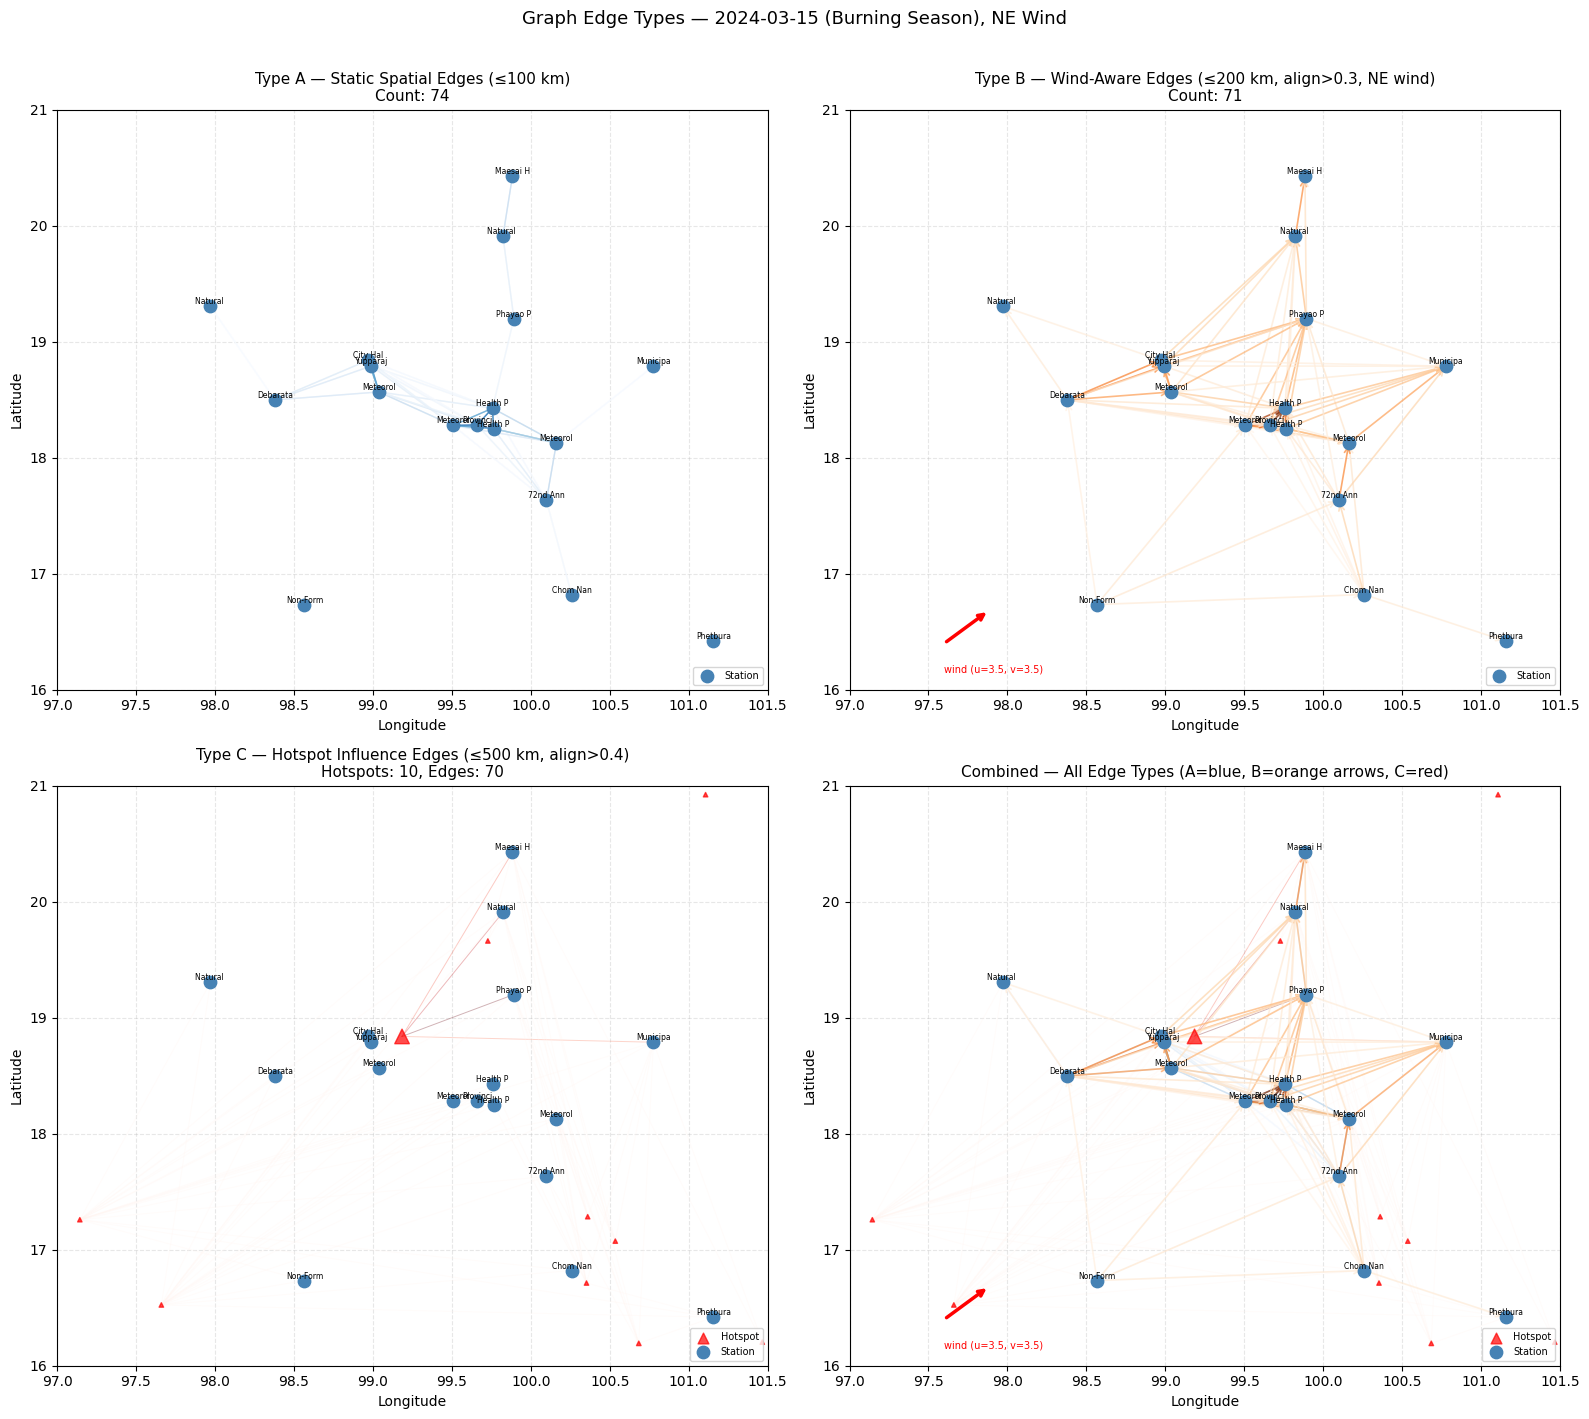

Saved: notebooks/figures/graph_edge_types.png


In [5]:
# Cell 5 — Edge type figures (3 individual + 1 combined)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

# Panel 1: Type A — static spatial edges
plot_graph(
    axes[0], df_stations, df_hotspots, graph_ne,
    edge_type="type_a",
    title=(
        "Type A \u2014 Static Spatial Edges (\u2264100 km)\n"
        f"Count: {graph_ne['station', 'type_a', 'station'].edge_index.shape[1]}"
    ),
)

# Panel 2: Type B — wind-aware edges (NE wind)
plot_graph(
    axes[1], df_stations, df_hotspots, graph_ne,
    edge_type="type_b",
    title=(
        "Type B \u2014 Wind-Aware Edges (\u2264200 km, align>0.3, NE wind)\n"
        f"Count: {graph_ne['station', 'type_b', 'station'].edge_index.shape[1]}"
    ),
    wind_u=config_ne["synthetic_u"],
    wind_v=config_ne["synthetic_v"],
)

# Panel 3: Type C — hotspot influence edges
plot_graph(
    axes[2], df_stations, df_hotspots, graph_ne,
    edge_type="type_c",
    title=(
        "Type C \u2014 Hotspot Influence Edges (\u2264500 km, align>0.4)\n"
        f"Hotspots: {len(df_hotspots)}, "
        f"Edges: {graph_ne['hotspot', 'type_c', 'station'].edge_index.shape[1]}"
    ),
)

# Panel 4: Combined — all three edge types
plot_graph(
    axes[3], df_stations, df_hotspots, graph_ne,
    edge_type="all",
    title="Combined \u2014 All Edge Types (A=blue, B=orange arrows, C=red)",
    wind_u=config_ne["synthetic_u"],
    wind_v=config_ne["synthetic_v"],
)

plt.suptitle(
    "Graph Edge Types \u2014 2024-03-15 (Burning Season), NE Wind",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.savefig("notebooks/figures/graph_edge_types.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: notebooks/figures/graph_edge_types.png")

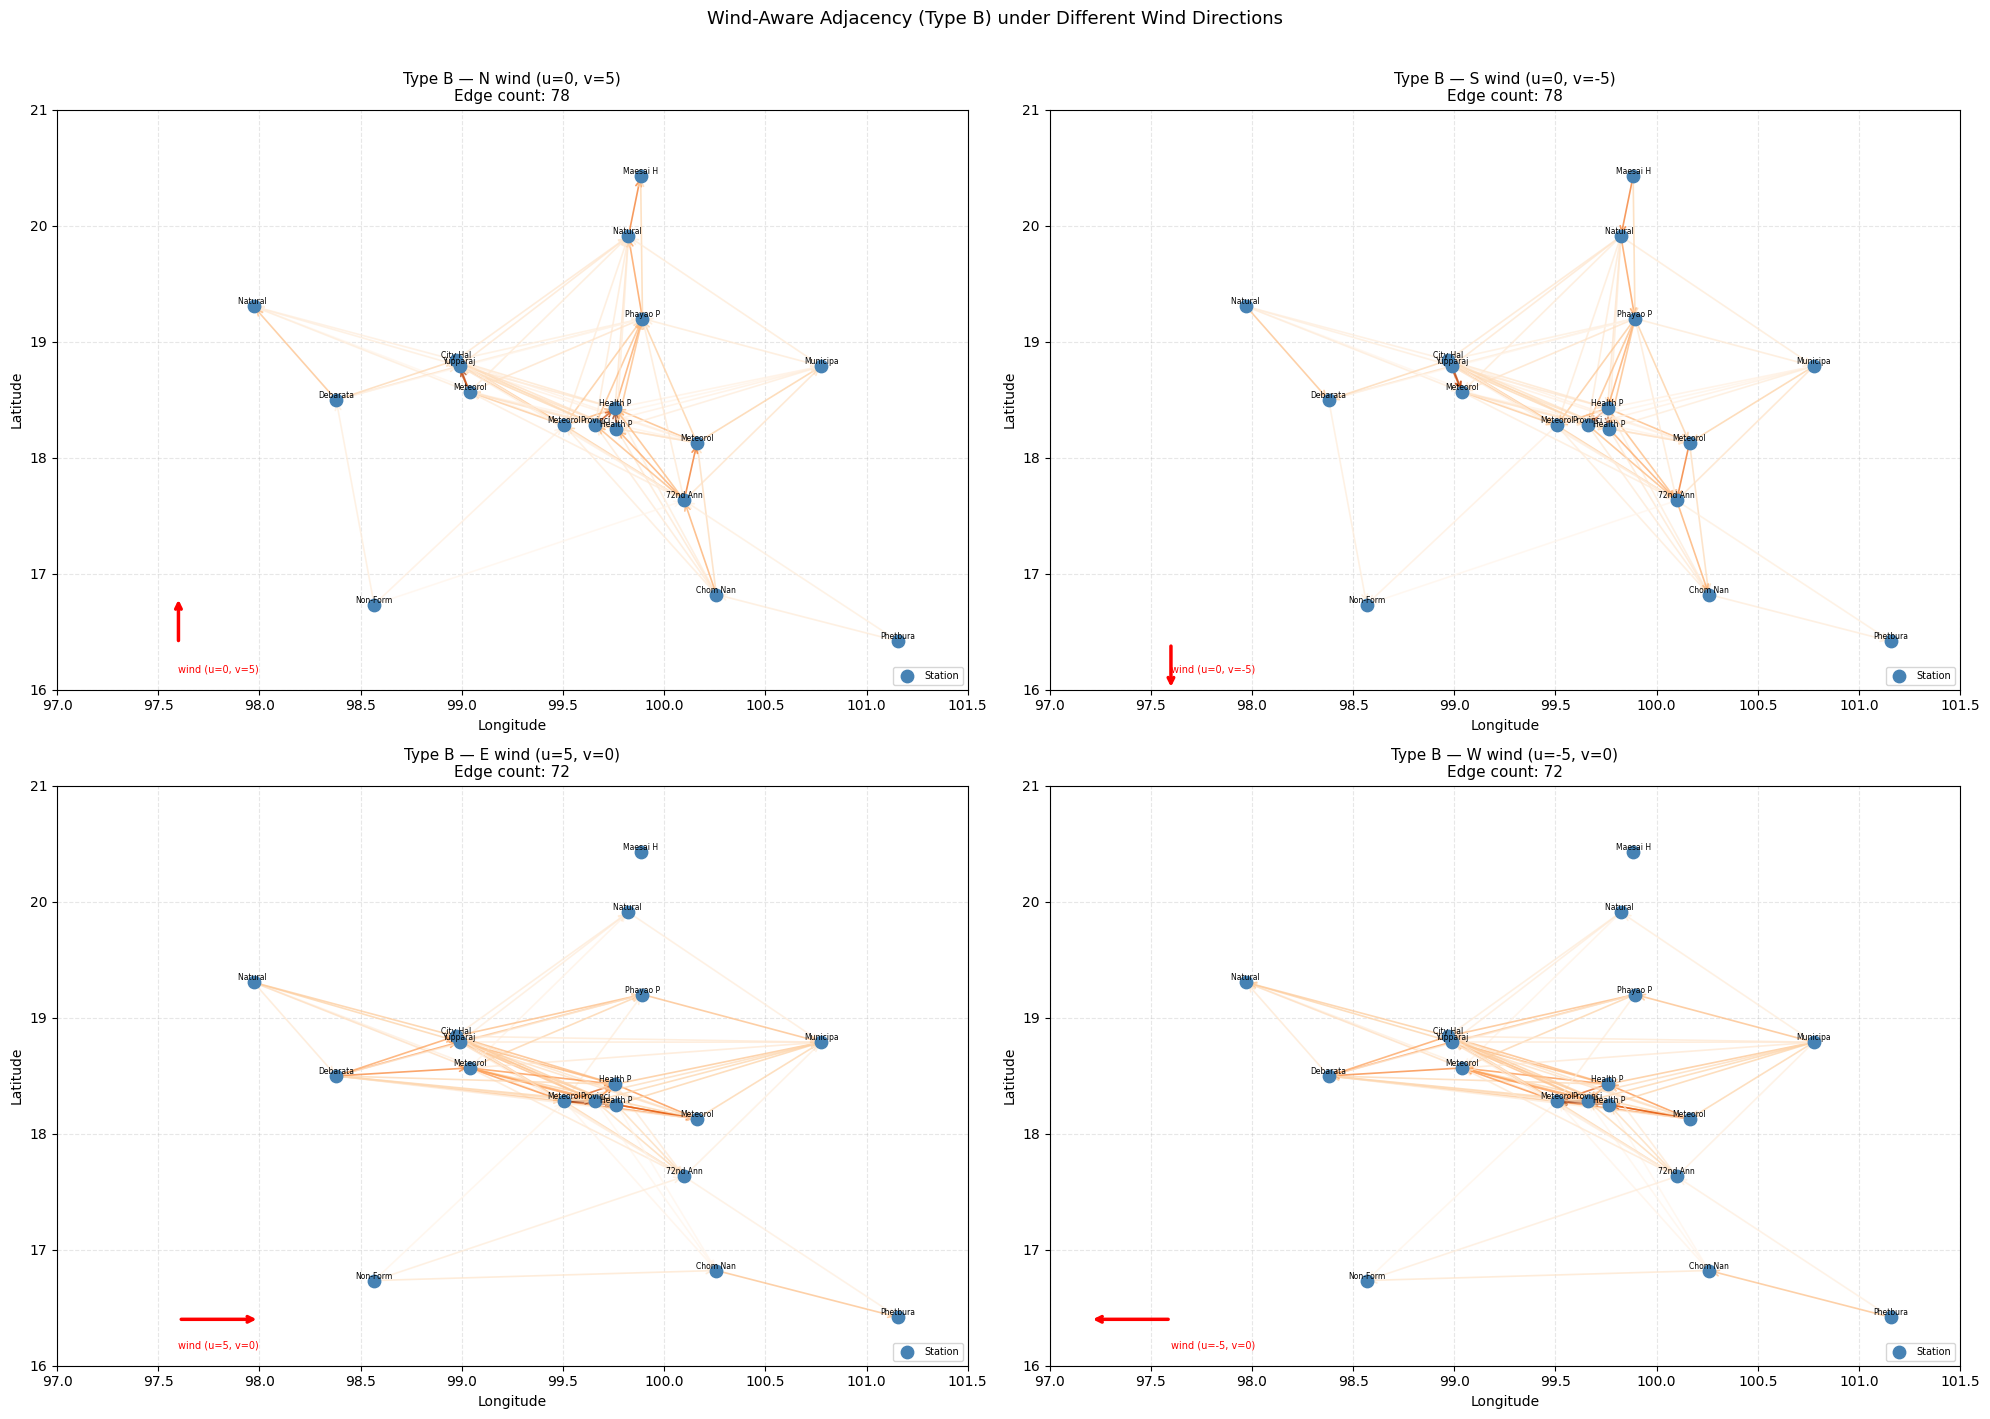

Saved: notebooks/figures/wind_direction_demo.png


In [6]:
# Cell 6 — Wind direction demo (Type B edges under 4 wind directions)
wind_configs = {
    "N wind (u=0, v=5)":   {"wind_mode": "constant_ne", "synthetic_u": 0,  "synthetic_v":  5},
    "S wind (u=0, v=-5)":  {"wind_mode": "constant_ne", "synthetic_u": 0,  "synthetic_v": -5},
    "E wind (u=5, v=0)":   {"wind_mode": "constant_ne", "synthetic_u": 5,  "synthetic_v":  0},
    "W wind (u=-5, v=0)":  {"wind_mode": "constant_ne", "synthetic_u": -5, "synthetic_v":  0},
}

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

for ax, (label, wcfg) in zip(axes, wind_configs.items()):
    full_cfg = {**_DEFAULT_CONFIG, **wcfg}
    graph_w = build_graph(df_stations, df_hotspots, None, full_cfg)
    n_edges_b = graph_w["station", "type_b", "station"].edge_index.shape[1]
    plot_graph(
        ax, df_stations, df_hotspots, graph_w,
        edge_type="type_b",
        title=f"Type B \u2014 {label}\nEdge count: {n_edges_b}",
        wind_u=wcfg["synthetic_u"],
        wind_v=wcfg["synthetic_v"],
    )

plt.suptitle(
    "Wind-Aware Adjacency (Type B) under Different Wind Directions",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.savefig("notebooks/figures/wind_direction_demo.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: notebooks/figures/wind_direction_demo.png")

Hotspot records in burning season 2024 (Feb–Apr): 3350
Countries: {'Thailand': 2863, 'Myanmar': 462, 'Laos': 25}


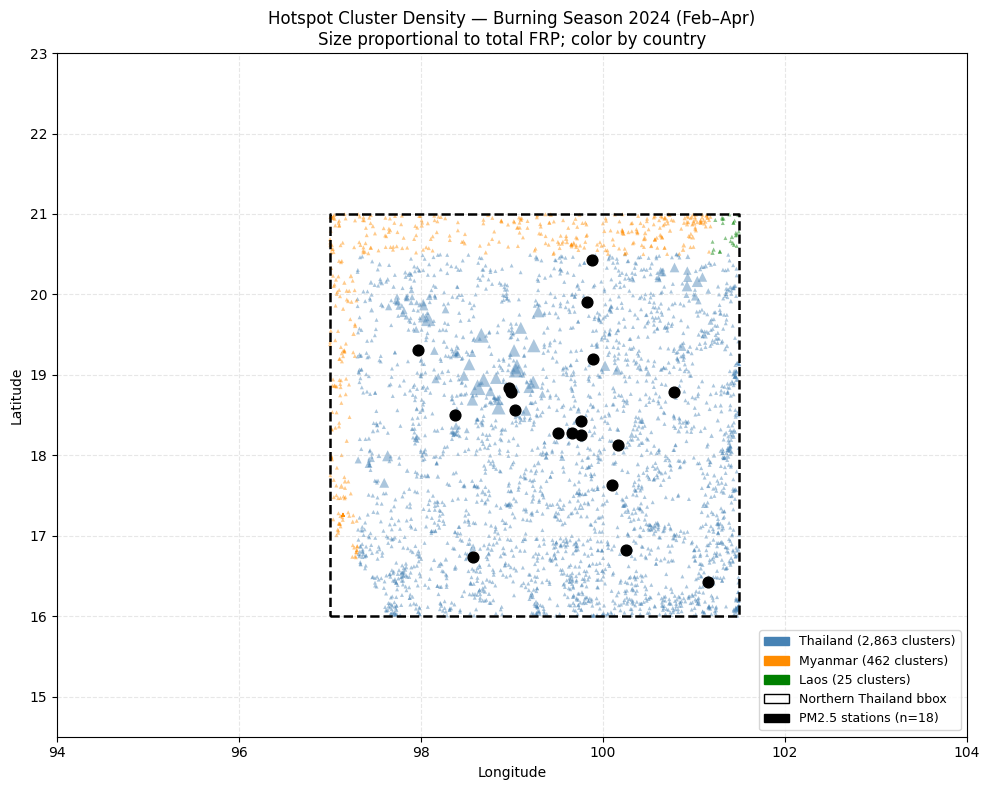

Saved: notebooks/figures/hotspot_heatmap.png


In [7]:
# Cell 7 — Hotspot density heatmap (Feb-Apr 2024, burning season)
burn_start = pd.to_datetime("2024-02-01").date()
burn_end = pd.to_datetime("2024-04-30").date()

df_burn = df_hotspots_all[
    df_hotspots_all["date"].apply(_to_date).between(burn_start, burn_end)
].copy()

print(f"Hotspot records in burning season 2024 (Feb\u2013Apr): {len(df_burn)}")
print(f"Countries: {df_burn['country'].value_counts().to_dict()}")

# Color mapping by country
country_colors = {
    "Thailand": "steelblue",
    "Myanmar":  "darkorange",
    "Laos":     "green",
}
default_color = "gray"

fig, ax = plt.subplots(figsize=(10, 8))

frp_all = df_burn["total_frp"].values
frp_max = float(frp_all.max()) if len(frp_all) > 0 else 1.0

legend_handles = []
for country, color in country_colors.items():
    subset = df_burn[df_burn["country"] == country]
    if subset.empty:
        continue
    frp_norm = subset["total_frp"].values / frp_max * 120 + 8
    ax.scatter(
        subset["centroid_lon"], subset["centroid_lat"],
        c=color, s=frp_norm, alpha=0.45, marker="^", edgecolors="none",
    )
    legend_handles.append(
        mpatches.Patch(color=color, label=f"{country} ({len(subset):,} clusters)")
    )

# Other countries not in the explicit mapping
other = df_burn[~df_burn["country"].isin(country_colors.keys())]
if not other.empty:
    frp_norm = other["total_frp"].values / frp_max * 120 + 8
    ax.scatter(
        other["centroid_lon"], other["centroid_lat"],
        c=default_color, s=frp_norm, alpha=0.4, marker="^", edgecolors="none",
    )
    legend_handles.append(
        mpatches.Patch(color=default_color, label=f"Other ({len(other):,} clusters)")
    )

# Northern Thailand bounding box
bbox_lon = [97.0, 101.5, 101.5, 97.0, 97.0]
bbox_lat = [16.0, 16.0,  21.0,  21.0, 16.0]
ax.plot(bbox_lon, bbox_lat, "k--", linewidth=1.8)
legend_handles.append(
    mpatches.Patch(
        facecolor="none", edgecolor="black",
        label="Northern Thailand bbox",
    )
)

# Station markers for spatial context
ax.scatter(
    df_stations["lon"], df_stations["lat"],
    c="black", s=60, zorder=6, marker="o",
)
legend_handles.append(
    mpatches.Patch(color="black", label=f"PM2.5 stations (n={len(df_stations)})")
)

ax.set_xlim(94.0, 104.0)
ax.set_ylim(14.5, 23.0)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(
    "Hotspot Cluster Density \u2014 Burning Season 2024 (Feb\u2013Apr)\n"
    "Size proportional to total FRP; color by country",
    fontsize=12,
)
ax.legend(handles=legend_handles, fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig("notebooks/figures/hotspot_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: notebooks/figures/hotspot_heatmap.png")

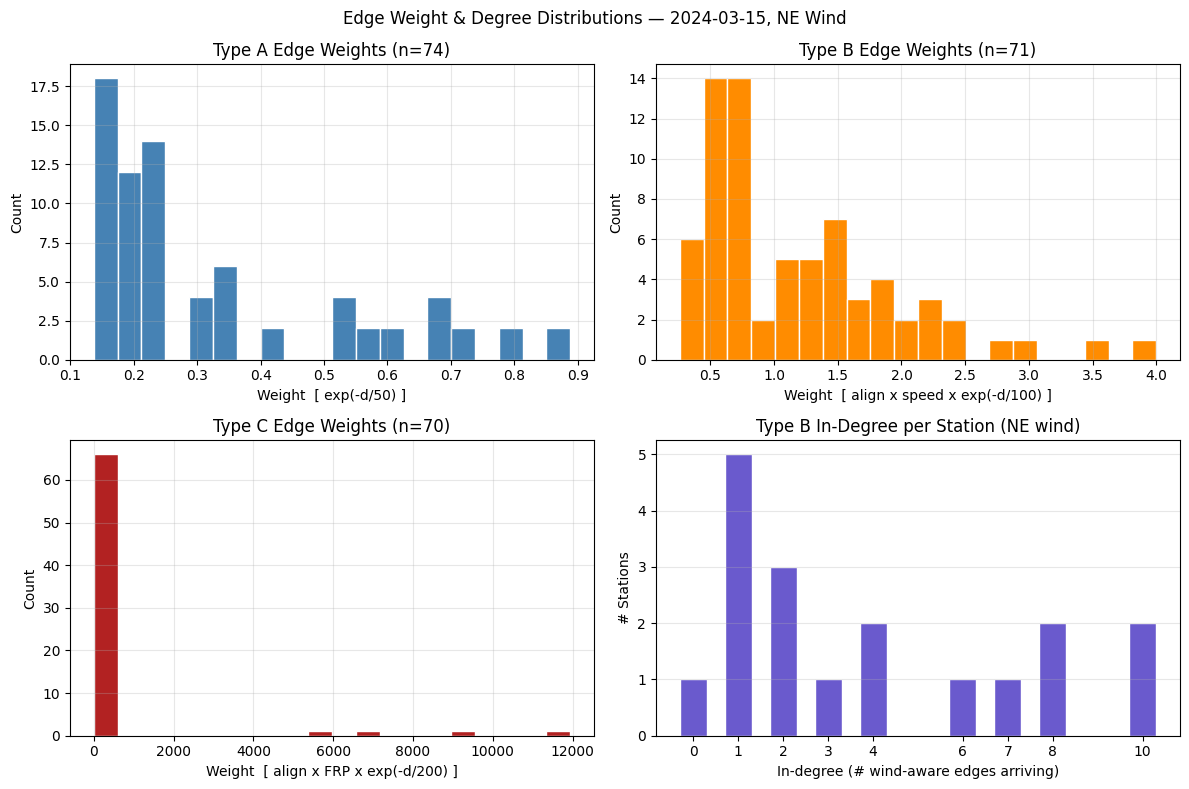

Saved: notebooks/figures/edge_distributions.png


In [8]:
# Cell 8 — Edge weight & degree distributions
ea_a = graph_ne["station", "type_a", "station"].edge_attr.numpy()
ea_b = graph_ne["station", "type_b", "station"].edge_attr.numpy()
ea_c = graph_ne["hotspot", "type_c", "station"].edge_attr.numpy()
ei_b = graph_ne["station", "type_b", "station"].edge_index.numpy()

n_stations = len(df_stations)

# In-degree per station for Type B (how many wind-carrying edges arrive)
in_degree_b = np.zeros(n_stations, dtype=int)
if ei_b.shape[1] > 0:
    for t in ei_b[1, :]:
        in_degree_b[t] += 1

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Subplot 1: Type A weight histogram
ax = axes[0, 0]
if ea_a.shape[0] > 0:
    ax.hist(ea_a[:, 0], bins=20, color="steelblue", edgecolor="white")
else:
    ax.text(0.5, 0.5, "No Type A edges", ha="center", va="center", transform=ax.transAxes)
ax.set_title(f"Type A Edge Weights (n={ea_a.shape[0]})")
ax.set_xlabel("Weight  [ exp(-d/50) ]")
ax.set_ylabel("Count")
ax.grid(True, alpha=0.3)

# Subplot 2: Type B weight histogram
ax = axes[0, 1]
if ea_b.shape[0] > 0:
    ax.hist(ea_b[:, 0], bins=20, color="darkorange", edgecolor="white")
else:
    ax.text(0.5, 0.5, "No Type B edges", ha="center", va="center", transform=ax.transAxes)
ax.set_title(f"Type B Edge Weights (n={ea_b.shape[0]})")
ax.set_xlabel("Weight  [ align x speed x exp(-d/100) ]")
ax.set_ylabel("Count")
ax.grid(True, alpha=0.3)

# Subplot 3: Type C weight histogram
ax = axes[1, 0]
if ea_c.shape[0] > 0:
    ax.hist(ea_c[:, 0], bins=20, color="firebrick", edgecolor="white")
else:
    ax.text(0.5, 0.5, "No Type C edges", ha="center", va="center", transform=ax.transAxes)
ax.set_title(f"Type C Edge Weights (n={ea_c.shape[0]})")
ax.set_xlabel("Weight  [ align x FRP x exp(-d/200) ]")
ax.set_ylabel("Count")
ax.grid(True, alpha=0.3)

# Subplot 4: Node in-degree distribution for Type B
ax = axes[1, 1]
unique_deg, counts = np.unique(in_degree_b, return_counts=True)
ax.bar(unique_deg, counts, color="slateblue", edgecolor="white", width=0.6)
ax.set_title("Type B In-Degree per Station (NE wind)")
ax.set_xlabel("In-degree (# wind-aware edges arriving)")
ax.set_ylabel("# Stations")
ax.set_xticks(unique_deg)
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Edge Weight & Degree Distributions \u2014 2024-03-15, NE Wind", fontsize=12)
plt.tight_layout()
plt.savefig("notebooks/figures/edge_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: notebooks/figures/edge_distributions.png")

## สรุปการสร้างกราฟ

### จำนวนเส้นเชื่อม (Reference: 15 มีนาคม 2024, ลมทิศตะวันออกเฉียงเหนือ)

| ประเภท | คำอธิบาย | เกณฑ์ | ทิศทาง |
|--------|-----------|--------|--------|
| **Type A** | เชิงพื้นที่แบบสถิต | ระยะ ≤ 100 กม. | ไม่มีทิศทาง (undirected) |
| **Type B** | ตามทิศทางลม | ระยะ ≤ 200 กม., alignment > 0.3 | มีทิศทาง (directed) |
| **Type C** | อิทธิพลจุดเผา | ระยะ ≤ 500 กม., alignment > 0.4 | มีทิศทาง (hotspot → สถานี) |

### ผลการวิเคราะห์

**ผลของทิศทางลมต่อ Type B:**  
เมื่อเปลี่ยนทิศทางลม จะเห็นว่าจำนวนและตำแหน่งของเส้นเชื่อม Type B เปลี่ยนแปลงอย่างชัดเจน  
ลมทิศเหนือ (v=5) ทำให้เกิดเส้นเชื่อมจากสถานีทางใต้ไปยังสถานีทางเหนือ  
ลมทิศใต้ (v=-5) เกิดเส้นเชื่อมตรงข้าม  
ลมทิศตะวันตก (u=-5) ทำให้สถานีทางตะวันออกได้รับอิทธิพลจากสถานีทางตะวันตก

**อิทธิพลจุดเผาไหม้ (Type C):**  
ในช่วงฤดูเผาไหม้ (กุมภาพันธ์–เมษายน) มีกลุ่มจุดเผาไหม้จำนวนมากในพม่าและลาว  
ซึ่งส่งอิทธิพลข้ามพรมแดนมายังสถานีในภาคเหนือของไทย โดยเฉพาะเมื่อลมพัดมาจากทิศตะวันตกเฉียงเหนือ  
น้ำหนักของเส้นเชื่อม Type C ขึ้นกับ FRP (Fire Radiative Power) × alignment × exp(−ระยะ/200)

**การกระจายน้ำหนักของเส้นเชื่อม:**  
- Type A: น้ำหนักอยู่ในช่วง (0, 1] ขึ้นกับระยะทาง (สูตร exp(-d/50))
- Type B: น้ำหนักแปรตามความเร็วลม × alignment × exp(-d/100)
- Type C: น้ำหนักแปรตาม FRP ซึ่งมีช่วงกว้างกว่า สะท้อนความรุนแรงของไฟ